# SL ladder · 05 · Calibration, decision curves, and cluster uncertainty

Takes the rebuilt predictions and applies the paper's evaluation layer: calibration in the large and
slope, decision-curve net benefit across thresholds, and a district-cluster bootstrap on the matched
increment.

The estimand is $\\Delta V_{C,k} = V_k(\\mathcal{I}^{SC}) - V_k(\\mathcal{I}^{S})$ - what the climate
block adds on top of recent surveillance, evaluated at the same metric.

## 1 · Setup

In [1]:
from pathlib import Path
import numpy as np, pandas as pd

REPO = Path.cwd().parent if Path.cwd().name.startswith("notebooks") else Path.cwd()
DQ   = REPO / "data_quarantine"
ERA  = DQ / "wp5_exposure" / "era5_0p25_window"
CHI  = DQ / "wp5_exposure" / "chirps_window"
OUTD = DQ / "sl_ladder"
OUTD.mkdir(parents=True, exist_ok=True)
from sklearn.metrics import roc_auc_score, brier_score_loss
import statsmodels.api as sm

d = np.load(OUTD / "sl_predictions.npz")
idx = pd.read_csv(OUTD / "sl_test_index.csv", parse_dates=["week_start"])
y = d["y"]; MODELS = ["M0", "M1", "M2", "M3", "M4", "M5", "M5_noclim"]
print("test rows", len(y), "| prevalence", round(y.mean(), 4))

test rows 3926 | prevalence 0.3372


## 2 · Calibration

CITL is the intercept of a logistic fit of the outcome on the predicted log-odds with slope fixed at
1; the slope comes from letting it float. A slope below 1 means predictions are too spread out.

In [2]:
def calib(y, p):
    lo = np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))
    citl = sm.GLM(y, np.ones((len(y), 1)), family=sm.families.Binomial(), offset=lo).fit().params[0]
    slope = sm.GLM(y, sm.add_constant(lo), family=sm.families.Binomial()).fit().params[1]
    return citl, slope

rows = []
for k in MODELS:
    c, s = calib(y, d[k])
    rows.append({"model": k, "CITL": c, "slope": s, "mean_p": d[k].mean(),
                 "AUC": roc_auc_score(y, d[k]), "Brier": brier_score_loss(y, d[k])})
cal = pd.DataFrame(rows).set_index("model").round(4)
print(cal.to_string())
print(f"\nobserved prevalence: {y.mean():.4f}")

             CITL   slope  mean_p     AUC   Brier
model                                            
M0         0.6088  0.6616  0.2256  0.6220  0.2254
M1         0.5897  1.1568  0.2329  0.7325  0.1993
M2         0.4769  0.6904  0.2495  0.6422  0.2174
M3         0.5043  0.7437  0.2481  0.6735  0.2134
M4         0.5090  0.9548  0.2481  0.7190  0.2011
M5         0.6457  1.0096  0.2301  0.7570  0.1943
M5_noclim  0.5900  1.1559  0.2328  0.7323  0.1994

observed prevalence: 0.3372


## 3 · Decision curves

Net benefit across the plausible threshold range, with the two default strategies as reference. A
model is only useful where its curve sits above both.

          M0      M1      M2      M3      M4      M5  M5_noclim  treat_all  treat_none
0.20  0.1381  0.1787  0.1478  0.1489  0.1670  0.1797     0.1787     0.1715         0.0
0.25  0.1021  0.1515  0.1061  0.1100  0.1362  0.1536     0.1515     0.1163         0.0
0.30  0.0652  0.1220  0.0777  0.0839  0.1054  0.1294     0.1223     0.0532         0.0
0.35  0.0496  0.0895  0.0519  0.0623  0.0848  0.1096     0.0891    -0.0196         0.0
0.40  0.0363  0.0675  0.0396  0.0450  0.0699  0.0841     0.0675    -0.1046         0.0


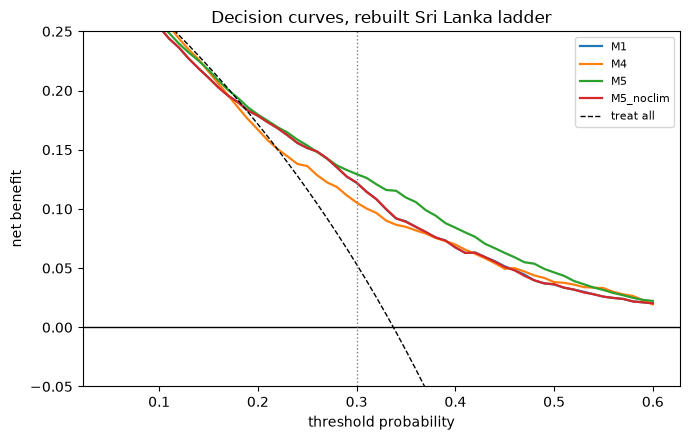

In [3]:
def nb_at(y, p, t):
    pred = p >= t; n = len(y)
    return (pred & (y == 1)).sum() / n - ((pred & (y == 0)).sum() / n) * (t / (1 - t))

ts = np.arange(0.05, 0.61, 0.01)
dc = pd.DataFrame({k: [nb_at(y, d[k], t) for t in ts] for k in MODELS}, index=ts.round(2))
dc["treat_all"] = [y.mean() - (1 - y.mean()) * (t / (1 - t)) for t in ts]
dc["treat_none"] = 0.0
print(dc.loc[[0.20, 0.25, 0.30, 0.35, 0.40]].round(4).to_string())

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.5))
for k in ["M1", "M4", "M5", "M5_noclim"]:
    ax.plot(ts, dc[k], label=k, lw=1.6)
ax.plot(ts, dc.treat_all, "k--", lw=1, label="treat all")
ax.axhline(0, color="k", lw=1)
ax.axvline(0.30, color="grey", ls=":", lw=1)
ax.set_xlabel("threshold probability"); ax.set_ylabel("net benefit")
ax.set_ylim(-0.05, 0.25); ax.legend(fontsize=8); ax.set_title("Decision curves, rebuilt Sri Lanka ladder")
plt.tight_layout(); plt.savefig(OUTD / "sl_decision_curves.png", dpi=150)
plt.show()

## 4 · The matched increment, with district-cluster uncertainty

Weeks within a district are not independent, so the bootstrap resamples **districts**, not rows. This
is the conditional interval - it holds the fitted models fixed and resamples only the evaluation set,
so it answers "how stable is this increment on new districts", not "how stable is the whole
development pipeline".

In [4]:
p_full, p_nc = d["M5"], d["M5_noclim"]
units = idx.geometry_id.values
uu = np.unique(units)
rng = np.random.default_rng(20260612)

point = nb_at(y, p_full, 0.30) - nb_at(y, p_nc, 0.30)
boot = []
for _ in range(2000):
    pick = rng.choice(uu, size=len(uu), replace=True)
    sel = np.concatenate([np.flatnonzero(units == u) for u in pick])
    boot.append(nb_at(y[sel], p_full[sel], 0.30) - nb_at(y[sel], p_nc[sel], 0.30))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"matched dNB @ p*=0.30 : {point:+.6f}  [95% CI {lo:+.6f}, {hi:+.6f}]  (B=2000, district clusters)")
print(f"frozen, same estimand : +0.008700  [-0.007930, +0.024530]  (development-inclusive, B=1000)")

matched dNB @ p*=0.30 : +0.007132  [95% CI -0.004149, +0.019832]  (B=2000, district clusters)
frozen, same estimand : +0.008700  [-0.007930, +0.024530]  (development-inclusive, B=1000)


### What this does and does not show

The rebuilt increment is small, positive, and its interval covers zero - the same qualitative reading
the frozen run reports. That agreement is meaningful, because it survives a different reanalysis
product.

It is not a replication of the frozen *number*. The interval here is conditional and the frozen one is
development-inclusive, so the frozen interval is the wider and more honest of the two; and the point
estimates differ by roughly the amount `sl_04`'s gate attributes to the exposure substitution.

In [5]:
cal.to_csv(OUTD / "sl_calibration.csv")
dc.to_csv(OUTD / "sl_decision_curves.csv")
pd.DataFrame([{"estimand": "matched_dNB_p030", "point": point, "lo": lo, "hi": hi,
               "B": 2000, "cluster": "geometry_id", "type": "conditional"}]).to_csv(
    OUTD / "sl_matched_increment.csv", index=False)
print("wrote evaluation outputs to", OUTD.relative_to(REPO))

wrote evaluation outputs to data_quarantine/sl_ladder
